# Stage 1: Baseline Models

## Purpose

Stage 1 establishes the global baseline layer of the thesis pipeline. Its role is to learn contract-level structure from the weakly supervised contract universe, quantify how far weak supervision alone can go, and create a pretrained MLP backbone for the later few-shot adaptation stage.

## Design principle

The Stage 1 design distinguishes between weak supervision and target-department gold supervision:

- Logistics contracts remain in the Stage 1 weak-label universe.
- Logistics weak labels generated by Snorkel remain part of Stage 1 weak training.
- Logistics gold labels are excluded from Stage 1 supervised gold training.
- Logistics gold labels are reserved for Stage 2 adaptation and evaluation.

This distinction is central to the thesis argument. Stage 1 should learn a global renegotiation representation, while Stage 2 should be the first point at which the model receives target-department gold signal.


## 1. Imports and project setup

In [1]:
import sys
from pathlib import Path
import re

project_root = Path.cwd().parent
src_path = project_root / "src"

if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

print("project_root:", project_root)
print("src_path:", src_path)

project_root: /Users/Thomas/Desktop/Master Thesis
src_path: /Users/Thomas/Desktop/Master Thesis/src


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
torch.set_num_threads(4) 


from master_thesis.config import FIGURES, MODELS_STAGE1, SEED
from master_thesis.data_utils import (
    load_processed,
    require_columns,
    make_gold_contract_split,
    save_table_versioned,
    save_json_versioned,
)
from master_thesis.baselines import (
    ElasticNetConfig,
    XGBoostConfig,
    BaselineTrainingConfig,
)
from master_thesis.mlp import (
    MLPTrainingConfig,
    set_seed,
)
from master_thesis.stage1 import (
    Stage1ModelConfig,
    fit_stage1_conditions,
    evaluate_stage1_conditions,
    save_stage1_condition_artifacts,
)

## 2. Notebook Helpers

The helper functions below are kept in the notebook because they are specific to the Stage 1 experimental workflow. They handle feature availability flags, Stage 1 feature selection, and versioned figure export. Keeping them local makes the experimental setup easier to inspect and reproduce.


In [3]:
def get_stage1_feature_columns(
    df_input: pd.DataFrame,
    group_col: str,
    weak_target_col: str,
    gold_col: str,
) -> list[str]:
    leakage_cols = [
        "Unnamed: 0",
        group_col,
        "contract_number",
        "contract_name",
        "supplier_id",
        "supplier_number",
        "supplier_display_name",
        "moodys_bvd_id",
        "Company name Latin alphabet",
        "company_name",
        "gold_department",
        "target_renegotiate",
        weak_target_col,
        gold_col,
        "start_date",
        "expiration_date",
        "execution_at",
        "published_at",
        "contract_name_lower",
        "lf_yes_votes",
        "lf_no_votes",
        "lf_abstain_votes",
        "global_lifecycle_yes_votes",
        "global_lifecycle_no_votes",
        "global_financial_yes_votes",
        "global_financial_no_votes",
        "global_esg_yes_votes",
        "global_esg_no_votes",
        "global_news_yes_votes",
        "global_news_no_votes",
        "global_market_yes_votes",
        "global_market_no_votes",
        "global_supplier_macro_yes_votes",
        "global_supplier_macro_no_votes",
        "logistics_specific_yes_votes",
        "logistics_specific_no_votes",
    ]
    return [c for c in df_input.columns if c not in leakage_cols]


def save_figure_versioned(fig, stem: str, output_dir: Path | None = None, dpi: int = 300) -> Path:
    if output_dir is None:
        output_dir = FIGURES

    output_dir.mkdir(parents=True, exist_ok=True)
    pattern = re.compile(rf"^{re.escape(stem)}_v(\d{{3}})\.png$")
    versions = []

    for path in output_dir.glob(f"{stem}_v*.png"):
        match = pattern.match(path.name)
        if match:
            versions.append(int(match.group(1)))

    next_version = max(versions, default=0) + 1
    output_path = output_dir / f"{stem}_v{next_version:03d}.png"
    fig.savefig(output_path, bbox_inches="tight", dpi=dpi)
    return output_path


## 3. Data Loading and Stage 1 Setup

This section loads the weak-labeled dataset used by the Stage 1 baselines. The dataset contains the full contract universe with Snorkel probabilities and any available gold labels. At this stage, the goal is not yet to specialize to a target department, but to define the global baseline environment from which the later adaptation step can begin.


In [4]:
set_seed(SEED)
np.random.seed(SEED)

# EXPERIMENT SETUP 1: Change dataset here
DATA_FILENAME = "contract_with_features_labeled_with_gold.csv"

# EXPERIMENT SETUP 2: Change weak target column here
WEAK_TARGET_COL = "renegotiation_prob"

# EXPERIMENT SETUP 3: Change gold target column here
GOLD_COL = "gold_y"
GROUP_COL = "contract_id"
DEPARTMENT_COL = "department"

df_stage1 = load_processed(DATA_FILENAME, low_memory=False)


In [5]:
# Stage 1 dataset diagnostics
print("Stage 1 dataset overview")
print(f"Total rows: {len(df_stage1)}")
print(f"Unique contracts: {df_stage1[GROUP_COL].nunique()}")

if DEPARTMENT_COL in df_stage1.columns:
    print("\nDepartment distribution (top 10)")
    print(df_stage1[DEPARTMENT_COL].value_counts().head(10))

    if "Logistics" in df_stage1[DEPARTMENT_COL].values:
        logistics_rows = len(df_stage1[df_stage1[DEPARTMENT_COL] == "Logistics"])
        print(f"\nLogistics department found with {logistics_rows} rows.")
    else:
        print("\nWarning: Logistics department was not found in the Stage 1 dataset.")

print(f"\nWeak label column present ('{WEAK_TARGET_COL}'): {WEAK_TARGET_COL in df_stage1.columns}")
print(f"Gold label column present ('{GOLD_COL}'): {GOLD_COL in df_stage1.columns}")


Stage 1 dataset overview
Total rows: 9201
Unique contracts: 2209

Department distribution (top 10)
department
Devices & Needles                          2197
Raw Materials & Energy                     1555
Packaging Material                         1272
Quality, Production Services & Supplies    1044
Drug Substance Outsourcing                  943
Bioprocessing & Raw Materials               679
Drug Product Outsourcing                    589
Logistics                                   282
Alliance, Acquisitions & PPM CoE            270
Bioprocessing and Excipients                218
Name: count, dtype: int64

Logistics department found with 282 rows.

Weak label column present ('renegotiation_prob'): True
Gold label column present ('gold_y'): True


In [6]:
df_stage1.head()

,contract_id,contract_name,contract_status,contract_owner_cost_centre,terminated,term_type,start_date,expiration_date,supplier_id,supplier_number,...,market_data_available,has_environmental_appendix,contract_name_lower,renegotiation_prob,target_renegotiate,gold_department,gold_y,label_source,label_date,notes
0,9675,Bioreliance_Master_2018_MSA,published,7756.0,0,fixed,2018-05-21 00:00:00+00:00,2027-07-30 00:00:00+00:00,11544,38367,...,0,0,bioreliance_master_2018_msa,0.621413,1,NaN,NaN,NaN,NaN,NaN
1,9675,Bioreliance_Master_2018_MSA,published,7756.0,0,fixed,2018-05-21 00:00:00+00:00,2027-07-30 00:00:00+00:00,11544,38367,...,0,0,bioreliance_master_2018_msa,0.621413,1,NaN,NaN,NaN,NaN,NaN
2,9675,Bioreliance_Master_2018_MSA,published,7756.0,0,fixed,2018-05-21 00:00:00+00:00,2027-07-30 00:00:00+00:00,11544,38367,...,0,0,bioreliance_master_2018_msa,0.621413,1,NaN,NaN,NaN,NaN,NaN
3,9675,Bioreliance_Master_2018_MSA,published,7756.0,0,fixed,2018-05-21 00:00:00+00:00,2027-07-30 00:00:00+00:00,11544,38367,...,0,0,bioreliance_master_2018_msa,0.621413,1,NaN,NaN,NaN,NaN,NaN
4,9675,Bioreliance_Master_2018_MSA,published,7756.0,0,fixed,2018-05-21 00:00:00+00:00,2027-07-30 00:00:00+00:00,11544,38367,...,0,0,bioreliance_master_2018_msa,0.565277,1,NaN,NaN,NaN,NaN,NaN


In [7]:
require_columns(
    df_stage1,
    [WEAK_TARGET_COL, GOLD_COL, GROUP_COL, DEPARTMENT_COL],
    df_name="df_stage1",
)

print("Shape:", df_stage1.shape)
print("Unique contracts:", df_stage1[GROUP_COL].nunique())
print("Gold-labeled rows:", int(df_stage1[GOLD_COL].notna().sum()))
display(df_stage1.head(3))

Shape: (9201, 168)
Unique contracts: 2209
Gold-labeled rows: 533


,contract_id,contract_name,contract_status,contract_owner_cost_centre,terminated,term_type,start_date,expiration_date,supplier_id,supplier_number,...,market_data_available,has_environmental_appendix,contract_name_lower,renegotiation_prob,target_renegotiate,gold_department,gold_y,label_source,label_date,notes
0,9675,Bioreliance_Master_2018_MSA,published,7756.0,0,fixed,2018-05-21 00:00:00+00:00,2027-07-30 00:00:00+00:00,11544,38367,...,0,0,bioreliance_master_2018_msa,0.621413,1,NaN,NaN,NaN,NaN,NaN
1,9675,Bioreliance_Master_2018_MSA,published,7756.0,0,fixed,2018-05-21 00:00:00+00:00,2027-07-30 00:00:00+00:00,11544,38367,...,0,0,bioreliance_master_2018_msa,0.621413,1,NaN,NaN,NaN,NaN,NaN
2,9675,Bioreliance_Master_2018_MSA,published,7756.0,0,fixed,2018-05-21 00:00:00+00:00,2027-07-30 00:00:00+00:00,11544,38367,...,0,0,bioreliance_master_2018_msa,0.621413,1,NaN,NaN,NaN,NaN,NaN


## 3A. Gold Split Design and Logistics Handling

The split logic below implements the thesis design directly.

The weak-label universe remains global, including Logistics. This allows the weak-only models to learn from the full contract portfolio and from the Snorkel probabilities assigned to Logistics rows.

The supervised Stage 1 gold training sets, however, exclude the target department Logistics. This prevents target-department gold leakage into Stage 1 while still allowing Stage 1 to serve as the global pretraining layer for Stage 2.

As a result:

- Condition A uses weak labels from all departments, including Logistics.
- Conditions B and C use gold training labels only from non-Logistics departments.
- Logistics gold labels are reserved for Stage 2.


In [8]:
TARGET_DEPARTMENT = "Logistics"

gold_train_contract_ids, gold_test_contract_ids = make_gold_contract_split(
    df_stage1=df_stage1,
    seed=SEED,
    test_size=0.30,
)

df_gold = df_stage1[df_stage1[GOLD_COL].notna()].copy()

# Reserve target-department gold labels for Stage 2 only.
df_gold_target = df_gold[df_gold[DEPARTMENT_COL] == TARGET_DEPARTMENT].copy()
df_gold_non_target = df_gold[df_gold[DEPARTMENT_COL] != TARGET_DEPARTMENT].copy()

df_gold_train = df_gold_non_target[df_gold_non_target[GROUP_COL].isin(gold_train_contract_ids)].copy()
df_gold_test = df_gold_non_target[df_gold_non_target[GROUP_COL].isin(gold_test_contract_ids)].copy()

# Weak training remains global and may include Logistics weak labels.
# Only the held-out Stage 1 gold test contracts are removed from weak training.
df_weak_all = df_stage1.copy()
df_weak_train = df_weak_all[~df_weak_all[GROUP_COL].isin(gold_test_contract_ids)].copy()

print("Target department:", TARGET_DEPARTMENT)
print("Gold train contracts before target exclusion:", len(gold_train_contract_ids))
print("Gold test contracts before target exclusion:", len(gold_test_contract_ids))
print("Non-target gold train rows:", len(df_gold_train))
print("Non-target gold test rows:", len(df_gold_test))
print("Target-department gold rows reserved for Stage 2:", len(df_gold_target))
print("Weak train rows:", len(df_weak_train))
print()

print("Non-target gold train label counts")
print(df_gold_train[GOLD_COL].value_counts(dropna=False))
print("\nNon-target gold test label counts")
print(df_gold_test[GOLD_COL].value_counts(dropna=False))

if DEPARTMENT_COL in df_gold_train.columns:
    logistics_gold_train_rows = int((df_gold_train[DEPARTMENT_COL] == TARGET_DEPARTMENT).sum())
    logistics_gold_test_rows = int((df_gold_test[DEPARTMENT_COL] == TARGET_DEPARTMENT).sum())
    logistics_weak_train_rows = int((df_weak_train[DEPARTMENT_COL] == TARGET_DEPARTMENT).sum())

    print("\nLogistics separation diagnostics")
    print("Logistics rows in gold train:", logistics_gold_train_rows)
    print("Logistics rows in gold test:", logistics_gold_test_rows)
    print("Logistics rows in weak train:", logistics_weak_train_rows)

    if logistics_gold_train_rows > 0 or logistics_gold_test_rows > 0:
        raise ValueError(
            "Logistics gold labels were found in Stage 1 supervised splits. "
            "These labels must be reserved for Stage 2."
        )


Target department: Logistics
Gold train contracts before target exclusion: 65
Gold test contracts before target exclusion: 29
Non-target gold train rows: 328
Non-target gold test rows: 183
Target-department gold rows reserved for Stage 2: 22
Weak train rows: 9016

Non-target gold train label counts
gold_y
1.0    217
0.0    111
Name: count, dtype: int64

Non-target gold test label counts
gold_y
1.0    123
0.0     60
Name: count, dtype: int64

Logistics separation diagnostics
Logistics rows in gold train: 0
Logistics rows in gold test: 0
Logistics rows in weak train: 280


## 4. Feature Matrix Setup

After the split has enforced the target-department rule, this section constructs the Stage 1 feature matrices. The weak matrices remain global, whereas the supervised gold matrices are restricted to non-Logistics gold rows. This ensures that all downstream training conditions operate on feature sets derived from the same preprocessing logic while respecting the thesis data-separation principle.


In [9]:
feature_cols = get_stage1_feature_columns(
    df_input=df_stage1,
    group_col=GROUP_COL,
    weak_target_col=WEAK_TARGET_COL,
    gold_col=GOLD_COL,
)

X_weak_train_df = df_weak_train[feature_cols].copy()
y_weak_train = df_weak_train[WEAK_TARGET_COL].astype(float).values

X_weak_all_df = df_weak_all[feature_cols].copy()
y_weak_all = df_weak_all[WEAK_TARGET_COL].astype(float).values

X_gold_train_df = df_gold_train[feature_cols].copy()
y_gold_train = df_gold_train[GOLD_COL].astype(int).values

X_gold_test_df = df_gold_test[feature_cols].copy()
y_gold_test = df_gold_test[GOLD_COL].astype(int).values

print("Number of Stage 1 features:", len(feature_cols))
print("Weak train shape:", X_weak_train_df.shape)
print("Gold train shape:", X_gold_train_df.shape)
print("Gold test shape :", X_gold_test_df.shape)

Number of Stage 1 features: 154
Weak train shape: (9016, 154)
Gold train shape: (328, 154)
Gold test shape : (183, 154)


## 5. Hyperparameters

This cell defines the Stage 1 training configuration for the baseline models and the MLP backbone. The purpose is not to perform exhaustive hyperparameter search, but to maintain a stable and reproducible configuration for comparing weak-only, gold-only, and hybrid supervision under a common experimental setting.


In [10]:
baseline_config = BaselineTrainingConfig(
    elastic_net=ElasticNetConfig(
        alpha=0.005,
        l1_ratio=0.5,
        max_iter=1000,         
        random_state=SEED,
    ),
    xgboost=XGBoostConfig(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        min_child_weight=3,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.0,
        reg_lambda=1.0,
        random_state=SEED,
        n_jobs=4,               
    ),
)


mlp_config = MLPTrainingConfig(
    n_epochs=100,
    patience=10,
    lr=5e-4,
    weight_decay=1e-4,
    train_batch_size=256,
    val_batch_size=512,
    hidden_dim_1=256,
    hidden_dim_2=128,
    dropout=0.1,
)

stage1_config = Stage1ModelConfig(
    baseline_config=baseline_config,
    mlp_config=mlp_config,
)

# EXPERIMENT SETUP 4: Change hybrid training weights here
HYBRID_WEAK_WEIGHT = 1.0
HYBRID_GOLD_WEIGHT = 5.0

experiment_config = {
    "seed": SEED,
    "data_filename": DATA_FILENAME,
    "weak_target_col": WEAK_TARGET_COL,
    "gold_col": GOLD_COL,
    "group_col": GROUP_COL,
    "department_col": DEPARTMENT_COL,
    "hybrid_weak_weight": HYBRID_WEAK_WEIGHT,
    "hybrid_gold_weight": HYBRID_GOLD_WEIGHT,
    "baseline_config": {
        "elastic_net": baseline_config.elastic_net.__dict__,
        "xgboost": baseline_config.xgboost.__dict__,
        "scale_numeric_for_elastic_net": baseline_config.scale_numeric_for_elastic_net,
        "scale_numeric_for_xgboost": baseline_config.scale_numeric_for_xgboost,
        "add_numeric_missing_indicator": baseline_config.add_numeric_missing_indicator,
    },
    "mlp_config": mlp_config.__dict__,
}

## 6. Define Stage 1 Conditions

The three Stage 1 conditions are controlled experimental baselines rather than separate thesis pipelines.

**Condition A — Weak-only training**
- Trains on Snorkel probabilistic labels for the full contract universe.
- Includes Logistics weak labels.
- Provides the main Stage 1 pretraining path and the principal initialization candidate for Stage 2.

**Condition B — Gold-only training**
- Trains only on non-Logistics gold labels.
- Excludes Logistics gold labels from Stage 1 training.
- Serves as an ablation showing how far scarce gold supervision can go on its own.

**Condition C — Hybrid weak-plus-gold training**
- Trains on the global weak-label universe together with non-Logistics gold labels.
- Includes Logistics weak labels but excludes Logistics gold labels from supervised training.
- Serves as an ablation testing whether naive mixing of weak and gold supervision is sufficient, or whether Stage 2 adaptation is still needed.

Together, the three conditions provide the evidence base for the thesis narrative: weak supervision is useful, scarce gold labels alone are insufficient, and simple hybridization does not remove the need for later department adaptation.


In [11]:
conditions = {
    "A_weak_only": {
        "X_train_df": X_weak_train_df,
        "y_train": y_weak_train,
        "sample_weight": None,
    },
    "B_gold_only": {
        "X_train_df": X_gold_train_df,
        "y_train": y_gold_train.astype(float),
        "sample_weight": None,
    },
    "C_hybrid": {
        "X_train_df": pd.concat([X_weak_train_df, X_gold_train_df], axis=0).reset_index(drop=True),
        "y_train": np.concatenate([y_weak_train, y_gold_train.astype(float)]),
        "sample_weight": np.concatenate([
            np.full(len(y_weak_train), HYBRID_WEAK_WEIGHT, dtype=float),
            np.full(len(y_gold_train), HYBRID_GOLD_WEIGHT, dtype=float),
        ]),
    },
}

## 7. Train All Stage 1 Conditions

Each Stage 1 condition trains the same family of baselines:

- Mean predictor
- Elastic Net
- XGBoost
- MLP

This consistent model menu ensures that differences in performance can be interpreted as differences in supervision regime rather than differences in model availability.


In [12]:
trained_bundles = fit_stage1_conditions(
    conditions=conditions,
    X_val=X_gold_test_df,
    y_val=y_gold_test.astype(float),
    config=stage1_config,
    seed=SEED,
    verbose=True,
)


========== Starting Condition: A_weak_only ==========
[A_weak_only] Fitting Mean Predictor...
[A_weak_only] Mean Predictor fitting complete.
[A_weak_only] Fitting Elastic Net (this can take time if unscaled)...
[A_weak_only] Elastic Net fitting complete.
[A_weak_only] Fitting XGBoost...
[A_weak_only] XGBoost fitting complete.
[A_weak_only] Fitting PyTorch MLP...
Epoch 01 | Train Loss: 0.5686 | Val Loss: 17.6841 | Val RMSE: 0.8199 | Val MAE: 0.6725
Epoch 02 | Train Loss: 0.5029 | Val Loss: 0.4275 | Val RMSE: 0.3617 | Val MAE: 0.2506
Epoch 03 | Train Loss: 0.4880 | Val Loss: 0.5971 | Val RMSE: 0.3448 | Val MAE: 0.2647
Epoch 04 | Train Loss: 0.4809 | Val Loss: 1.6849 | Val RMSE: 0.5258 | Val MAE: 0.2923
Epoch 05 | Train Loss: 0.4751 | Val Loss: 1.4496 | Val RMSE: 0.5276 | Val MAE: 0.2978
Epoch 06 | Train Loss: 0.4725 | Val Loss: 1.9390 | Val RMSE: 0.7514 | Val MAE: 0.6175
Epoch 07 | Train Loss: 0.4720 | Val Loss: 4.5214 | Val RMSE: 0.5718 | Val MAE: 0.3274
Epoch 08 | Train Loss: 0.4679 |

/Users/Thomas/Desktop/Master Thesis/.venv/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.012e-02, tolerance: 7.344e-03
  model = cd_fast.enet_coordinate_descent(


[B_gold_only] Elastic Net fitting complete.
[B_gold_only] Fitting XGBoost...
[B_gold_only] XGBoost fitting complete.
[B_gold_only] Fitting PyTorch MLP...
Epoch 01 | Train Loss: 0.7121 | Val Loss: 6.5880 | Val RMSE: 0.8198 | Val MAE: 0.6721
Epoch 02 | Train Loss: 0.5197 | Val Loss: 12.5045 | Val RMSE: 0.8198 | Val MAE: 0.6721
Epoch 03 | Train Loss: 0.4428 | Val Loss: 16.4473 | Val RMSE: 0.8198 | Val MAE: 0.6721
Epoch 04 | Train Loss: 0.3934 | Val Loss: 18.2811 | Val RMSE: 0.8198 | Val MAE: 0.6721
Epoch 05 | Train Loss: 0.3544 | Val Loss: 19.3414 | Val RMSE: 0.8198 | Val MAE: 0.6721
Epoch 06 | Train Loss: 0.3345 | Val Loss: 19.6687 | Val RMSE: 0.8198 | Val MAE: 0.6721
Epoch 07 | Train Loss: 0.3062 | Val Loss: 19.4511 | Val RMSE: 0.8198 | Val MAE: 0.6721
Epoch 08 | Train Loss: 0.2765 | Val Loss: 18.8929 | Val RMSE: 0.8198 | Val MAE: 0.6721
Epoch 09 | Train Loss: 0.2596 | Val Loss: 18.0731 | Val RMSE: 0.8198 | Val MAE: 0.6721
Epoch 10 | Train Loss: 0.2436 | Val Loss: 17.3696 | Val RMSE: 0.

## 8. Evaluate All Trained Conditions

Stage 1 evaluation is organized into two layers.

### Layer A: Weak-label distillation diagnostics
These metrics compare model predictions against Snorkel's `renegotiation_prob`. Their purpose is diagnostic: they measure how closely a model imitates the weak supervisor.

### Layer B: Gold-label validity
These metrics evaluate discrimination, ranking quality, probability quality, and calibration against held-out gold labels from non-Logistics departments. This layer answers the more important question for the thesis: whether a model trained under each supervision regime generalizes to manually labeled contracts.

The Layer B results provide the empirical motivation for Stage 2. They show whether weak-only, gold-only, or hybrid Stage 1 training is sufficient, and therefore whether few-shot department adaptation remains necessary.


In [13]:
evaluation_results = evaluate_stage1_conditions(
    trained_bundles=trained_bundles,
    X_weak_eval=X_weak_all_df,
    y_weak_eval=y_weak_all,
    X_gold_eval=X_gold_test_df,
    y_gold_eval=y_gold_test,
    threshold=0.5,
    k_values=(5, 10, 20),
)

df_layer_a = evaluation_results["df_weak_results_all"].copy()
df_layer_b = evaluation_results["df_gold_results_all"].copy()

display(df_layer_a.sort_values(["rmse", "mae"], ascending=True))
display(df_layer_b.sort_values("gold_auroc", ascending=False))

,model,rmse,mae,r2,pred_mean,true_mean,condition,model_base
2,XGBoost_A_weak_only,0.005111,0.002041,9.997231e-01,0.549643,0.549803,A_weak_only,XGBoost
10,XGBoost_C_hybrid,0.056150,0.016325,9.665769e-01,0.549311,0.549803,C_hybrid,XGBoost
1,Elastic Net_A_weak_only,0.150122,0.112379,7.610907e-01,0.545582,0.549803,A_weak_only,Elastic Net
9,Elastic Net_C_hybrid,0.156213,0.115858,7.413090e-01,0.545024,0.549803,C_hybrid,Elastic Net
11,MLP_C_hybrid,0.291883,0.250411,9.684128e-02,0.766450,0.549803,C_hybrid,MLP
8,Mean Predictor_C_hybrid,0.307134,0.249285,-7.030422e-08,0.549884,0.549803,C_hybrid,Mean Predictor
0,Mean Predictor_A_weak_only,0.307159,0.249181,-1.681117e-04,0.545820,0.549803,A_weak_only,Mean Predictor
4,Mean Predictor_B_gold_only,0.326843,0.283346,-1.324630e-01,0.661585,0.549803,B_gold_only,Mean Predictor
3,MLP_A_weak_only,0.340755,0.278967,-2.309203e-01,0.272816,0.549803,A_weak_only,MLP
5,Elastic Net_B_gold_only,0.375983,0.281359,-4.985839e-01,0.410886,0.549803,B_gold_only,Elastic Net


,model,gold_auroc,gold_ap,gold_logloss,gold_brier,gold_ece,gold_f1,gold_accuracy,gold_pred_mean,gold_true_mean,...,recall_at_5,ndcg_at_5,precision_at_10,recall_at_10,ndcg_at_10,precision_at_20,recall_at_20,ndcg_at_20,condition,model_base
6,XGBoost_B_gold_only,0.910298,0.916095,0.904012,0.066996,0.088884,0.949807,0.928962,0.756981,0.672131,...,0.03252,0.911111,0.4,0.032520,0.911111,0.60,0.097561,0.911111,B_gold_only,XGBoost
1,Elastic Net_A_weak_only,0.904336,0.919316,0.683951,0.107090,0.119553,0.916667,0.879781,0.743507,0.672131,...,0.04065,0.921569,1.0,0.081301,0.921569,1.00,0.162602,0.921569,A_weak_only,Elastic Net
7,MLP_B_gold_only,0.891057,0.911702,6.588020,0.672056,0.672078,0.000000,0.327869,0.000053,0.672131,...,0.03252,0.853932,0.9,0.073171,0.905212,0.90,0.146341,0.899206,B_gold_only,MLP
9,Elastic Net_C_hybrid,0.890650,0.903258,0.751165,0.098400,0.123057,0.923664,0.890710,0.742936,0.672131,...,0.03252,0.897959,0.6,0.048780,0.897959,0.75,0.121951,0.897959,C_hybrid,Elastic Net
2,XGBoost_A_weak_only,0.890379,0.909551,0.932961,0.112951,0.140108,0.909774,0.868852,0.749783,0.672131,...,0.04065,0.915493,0.8,0.065041,0.915493,0.80,0.130081,0.915493,A_weak_only,XGBoost
10,XGBoost_C_hybrid,0.883875,0.898140,0.907082,0.088007,0.113541,0.933852,0.907104,0.736585,0.672131,...,0.03252,0.895522,0.5,0.040650,0.895522,0.70,0.113821,0.895522,C_hybrid,XGBoost
3,MLP_A_weak_only,0.867073,0.882468,0.427467,0.130850,0.122732,0.876033,0.836066,0.573193,0.672131,...,0.03252,0.660840,0.8,0.065041,0.716287,0.90,0.146341,0.816901,A_weak_only,MLP
11,MLP_C_hybrid,0.833604,0.855998,0.600722,0.157461,0.179951,0.866197,0.792350,0.852083,0.672131,...,0.03252,0.660840,0.9,0.073171,0.779908,0.90,0.146341,0.823210,C_hybrid,MLP
5,Elastic Net_B_gold_only,0.799051,0.786970,1.404612,0.149619,0.179442,0.839827,0.797814,0.600718,0.672131,...,0.03252,0.521739,0.9,0.073171,0.521739,0.55,0.089431,0.521739,B_gold_only,Elastic Net
0,Mean Predictor_A_weak_only,0.500000,0.672131,0.665727,0.236325,0.126311,0.803922,0.672131,0.545820,0.672131,...,0.00000,0.672131,0.2,0.016260,0.672131,0.60,0.097561,0.672131,A_weak_only,Mean Predictor


## 9. Save Versioned Tables and Stage 1 Pretrained Artifacts

This section saves the Stage 1 outputs required by the rest of the thesis pipeline. In particular, the MLP artifact and its preprocessor become the initialization assets used by Stage 2. The saved tables also provide the reproducible record of the Stage 1 comparisons reported in the thesis.


In [14]:
path_config = save_json_versioned(experiment_config, "stage1_experiment_config")
path_layer_a = save_table_versioned(df_layer_a, "stage1_layer_a_weak_distillation")
path_layer_b = save_table_versioned(df_layer_b, "stage1_layer_b_gold_evaluation")

saved_condition_paths = {}

for condition_name, trained_bundle in trained_bundles.items():
    condition_dir = MODELS_STAGE1 / condition_name

    saved_condition_paths[condition_name] = save_stage1_condition_artifacts(
        trained_bundle=trained_bundle,
        output_dir=condition_dir,
        save_xgb_importance=True,
    )

    history_path = save_table_versioned(
        trained_bundle["mlp_bundle"]["history"],
        f"stage1_mlp_history_{condition_name}",
    )
    saved_condition_paths[condition_name]["history_versioned_path"] = history_path

print("Saved config:", path_config)
print("Saved layer A table:", path_layer_a)
print("Saved layer B table:", path_layer_b)
saved_condition_paths

Saved config: /Users/Thomas/Desktop/Master Thesis/reports/tables/stage1_experiment_config_v014.json
Saved layer A table: /Users/Thomas/Desktop/Master Thesis/reports/tables/stage1_layer_a_weak_distillation_v014.csv
Saved layer B table: /Users/Thomas/Desktop/Master Thesis/reports/tables/stage1_layer_b_gold_evaluation_v014.csv


{'A_weak_only': {'weights_path': PosixPath('/Users/Thomas/Desktop/Master Thesis/models/stage_1/A_weak_only/mlp_pretrained.pt'),
  'preprocessor_path': PosixPath('/Users/Thomas/Desktop/Master Thesis/models/stage_1/A_weak_only/mlp_pretrained_preprocessor.joblib'),
  'history_path': PosixPath('/Users/Thomas/Desktop/Master Thesis/models/stage_1/A_weak_only/mlp_pretrained_history.csv'),
  'tabular_results_path': PosixPath('/Users/Thomas/Desktop/Master Thesis/models/stage_1/A_weak_only/tabular_results.csv'),
  'xgboost_feature_importance_path': PosixPath('/Users/Thomas/Desktop/Master Thesis/models/stage_1/A_weak_only/xgboost_feature_importance.csv'),
  'history_versioned_path': PosixPath('/Users/Thomas/Desktop/Master Thesis/reports/tables/stage1_mlp_history_A_weak_only_v014.csv')},
 'B_gold_only': {'weights_path': PosixPath('/Users/Thomas/Desktop/Master Thesis/models/stage_1/B_gold_only/mlp_pretrained.pt'),
  'preprocessor_path': PosixPath('/Users/Thomas/Desktop/Master Thesis/models/stage_1/

## 10. Plots

The following plots summarize the main Stage 1 findings:

- weak-label distillation RMSE
- gold-label AUROC
- gold-label log-loss
- MLP training history for each condition

These figures support the written comparison between weak-only, gold-only, and hybrid supervision and help justify the transition from Stage 1 to Stage 2.


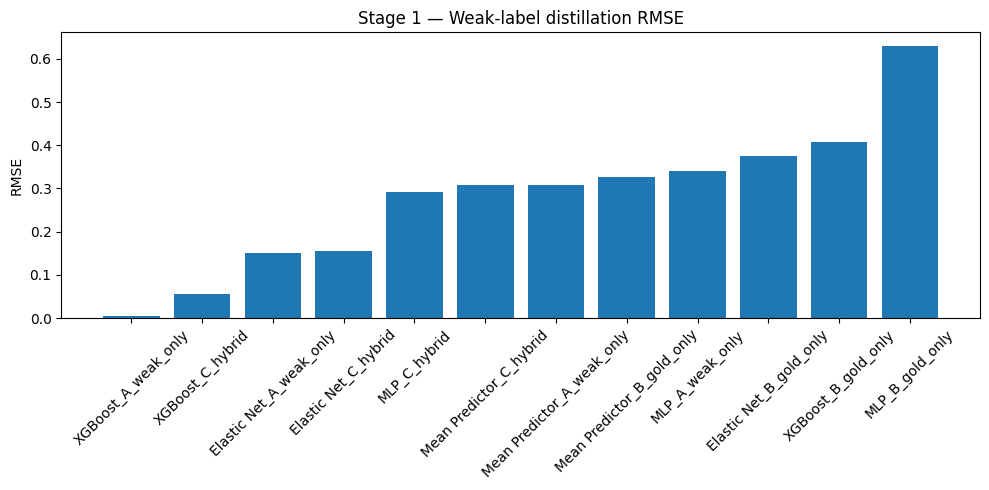

Saved figure: /Users/Thomas/Desktop/Master Thesis/reports/figures/stage1_layer_a_rmse_v014.png


In [15]:
# --- Plot 1: Layer A weak-label RMSE
df_plot_a = df_layer_a.sort_values("rmse", ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(df_plot_a["model"], df_plot_a["rmse"])
ax.set_title("Stage 1 — Weak-label distillation RMSE")
ax.set_ylabel("RMSE")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()

path_fig_a = save_figure_versioned(fig, "stage1_layer_a_rmse")
plt.show()

print("Saved figure:", path_fig_a)

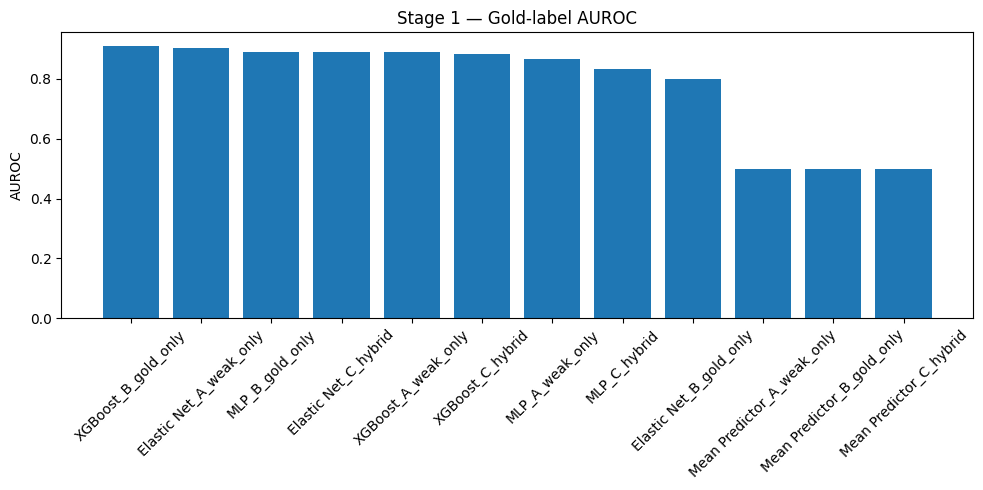

Saved figure: /Users/Thomas/Desktop/Master Thesis/reports/figures/stage1_gold_auroc_v014.png


In [16]:
# --- Plot 2: Layer B gold-label AUROC
df_plot_b_auc = df_layer_b.sort_values("gold_auroc", ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(df_plot_b_auc["model"], df_plot_b_auc["gold_auroc"])
ax.set_title("Stage 1 — Gold-label AUROC")
ax.set_ylabel("AUROC")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()

path_fig_b_auc = save_figure_versioned(fig, "stage1_gold_auroc")
plt.show()

print("Saved figure:", path_fig_b_auc)

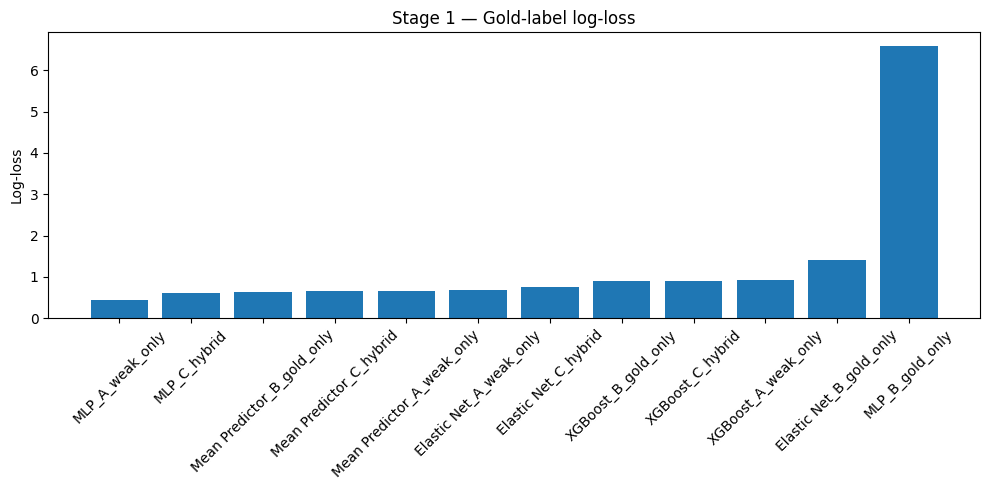

Saved figure: /Users/Thomas/Desktop/Master Thesis/reports/figures/stage1_gold_logloss_v014.png


In [17]:
# --- Plot 3: Layer B gold-label log-loss
df_plot_b_logloss = df_layer_b.sort_values("gold_logloss", ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(df_plot_b_logloss["model"], df_plot_b_logloss["gold_logloss"])
ax.set_title("Stage 1 — Gold-label log-loss")
ax.set_ylabel("Log-loss")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()

path_fig_b_logloss = save_figure_versioned(fig, "stage1_gold_logloss")
plt.show()

print("Saved figure:", path_fig_b_logloss)

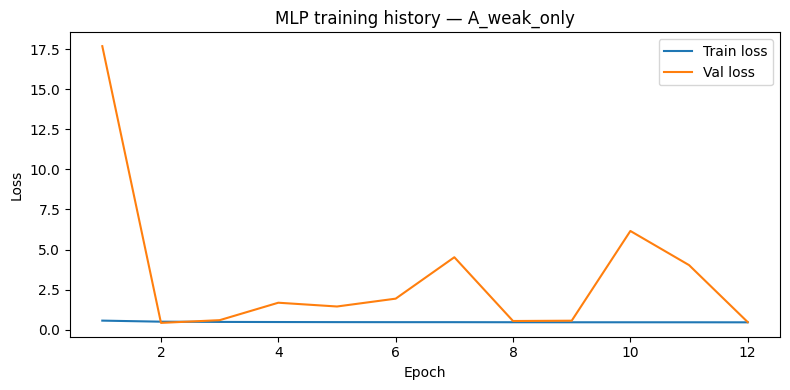

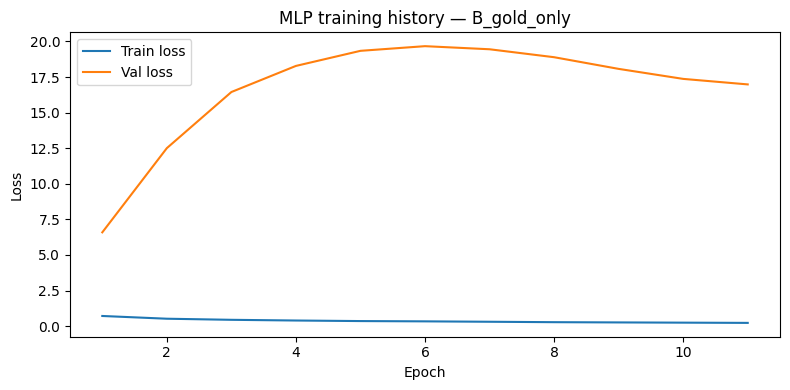

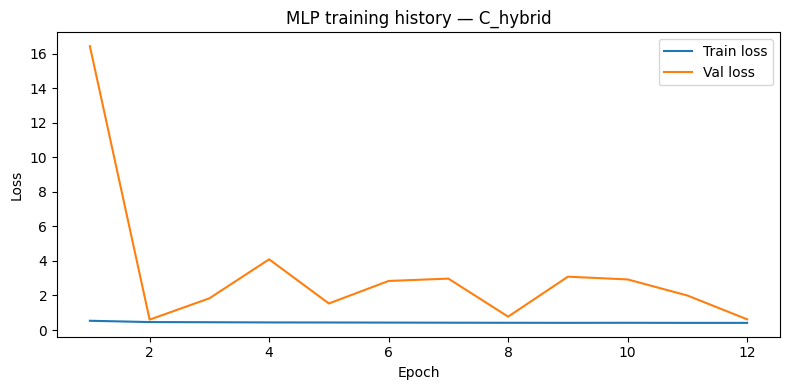

{'A_weak_only': PosixPath('/Users/Thomas/Desktop/Master Thesis/reports/figures/stage1_mlp_history_A_weak_only_v014.png'),
 'B_gold_only': PosixPath('/Users/Thomas/Desktop/Master Thesis/reports/figures/stage1_mlp_history_B_gold_only_v014.png'),
 'C_hybrid': PosixPath('/Users/Thomas/Desktop/Master Thesis/reports/figures/stage1_mlp_history_C_hybrid_v014.png')}

In [18]:
# --- Plot 4: MLP training history per condition
mlp_history_paths = {}

for condition_name, trained_bundle in trained_bundles.items():
    df_history = trained_bundle["mlp_bundle"]["history"].copy()

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(df_history["epoch"], df_history["train_loss"], label="Train loss")
    ax.plot(df_history["epoch"], df_history["val_loss"], label="Val loss")
    ax.set_title(f"MLP training history — {condition_name}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend()
    plt.tight_layout()

    fig_path = save_figure_versioned(fig, f"stage1_mlp_history_{condition_name}")
    mlp_history_paths[condition_name] = fig_path
    plt.show()

mlp_history_paths

## 11. Final Summary Views

The final tables consolidate the Stage 1 evidence base. They should be interpreted as the baseline layer that precedes Stage 2 adaptation. In particular, the summary should be read together with the design rule that Logistics weak labels were allowed in Stage 1, while Logistics gold labels were held out from Stage 1 supervised training.


In [19]:
df_gold_summary = df_layer_b[
    [
        "model",
        "condition",
        "model_base",
        "gold_auroc",
        "gold_ap",
        "gold_logloss",
        "gold_brier",
        "gold_ece",
        "gold_f1",
        "gold_accuracy",
        "precision_at_5",
        "precision_at_10",
        "precision_at_20",
        "recall_at_5",
        "recall_at_10",
        "recall_at_20",
        "ndcg_at_5",
        "ndcg_at_10",
        "ndcg_at_20",
    ]
].copy()

display(df_gold_summary.sort_values(["gold_auroc", "gold_ap"], ascending=False))

,model,condition,model_base,gold_auroc,gold_ap,gold_logloss,gold_brier,gold_ece,gold_f1,gold_accuracy,precision_at_5,precision_at_10,precision_at_20,recall_at_5,recall_at_10,recall_at_20,ndcg_at_5,ndcg_at_10,ndcg_at_20
6,XGBoost_B_gold_only,B_gold_only,XGBoost,0.910298,0.916095,0.904012,0.066996,0.088884,0.949807,0.928962,0.8,0.4,0.60,0.03252,0.032520,0.097561,0.911111,0.911111,0.911111
1,Elastic Net_A_weak_only,A_weak_only,Elastic Net,0.904336,0.919316,0.683951,0.107090,0.119553,0.916667,0.879781,1.0,1.0,1.00,0.04065,0.081301,0.162602,0.921569,0.921569,0.921569
7,MLP_B_gold_only,B_gold_only,MLP,0.891057,0.911702,6.588020,0.672056,0.672078,0.000000,0.327869,0.8,0.9,0.90,0.03252,0.073171,0.146341,0.853932,0.905212,0.899206
9,Elastic Net_C_hybrid,C_hybrid,Elastic Net,0.890650,0.903258,0.751165,0.098400,0.123057,0.923664,0.890710,0.8,0.6,0.75,0.03252,0.048780,0.121951,0.897959,0.897959,0.897959
2,XGBoost_A_weak_only,A_weak_only,XGBoost,0.890379,0.909551,0.932961,0.112951,0.140108,0.909774,0.868852,1.0,0.8,0.80,0.04065,0.065041,0.130081,0.915493,0.915493,0.915493
10,XGBoost_C_hybrid,C_hybrid,XGBoost,0.883875,0.898140,0.907082,0.088007,0.113541,0.933852,0.907104,0.8,0.5,0.70,0.03252,0.040650,0.113821,0.895522,0.895522,0.895522
3,MLP_A_weak_only,A_weak_only,MLP,0.867073,0.882468,0.427467,0.130850,0.122732,0.876033,0.836066,0.8,0.8,0.90,0.03252,0.065041,0.146341,0.660840,0.716287,0.816901
11,MLP_C_hybrid,C_hybrid,MLP,0.833604,0.855998,0.600722,0.157461,0.179951,0.866197,0.792350,0.8,0.9,0.90,0.03252,0.073171,0.146341,0.660840,0.779908,0.823210
5,Elastic Net_B_gold_only,B_gold_only,Elastic Net,0.799051,0.786970,1.404612,0.149619,0.179442,0.839827,0.797814,0.8,0.9,0.55,0.03252,0.073171,0.089431,0.521739,0.521739,0.521739
0,Mean Predictor_A_weak_only,A_weak_only,Mean Predictor,0.500000,0.672131,0.665727,0.236325,0.126311,0.803922,0.672131,0.0,0.2,0.60,0.00000,0.016260,0.097561,0.672131,0.672131,0.672131
